# DCA Ingest
Dieses Notebook dient dem Einlesen, analysieren und exportieren von Daten des Digitalen Konstruktionsarchivs
Im ersten Schritt werden die Daten eines Verzeichnisses mithilfe von DROID analysiert.
Anschliessend können die Daten individuell analysiert werden.
Im letzten Schritt wird diese Analyse in RDF form festgehalten und zusammen mit den Metadaten des digitalen Materials exportiert.

## Imports und Setup

In [1]:
%pip install pandas matplotlib pywaffle seaborn rdflib ipywidgets
# =====================================================
# ENVIRONMENT SETUP & DEPENDENCIES
# =====================================================

from pathlib import Path
import pandas as pd
import csv
import json, subprocess, hashlib, sys, math, re, os, shutil
from datetime import datetime
from typing import Optional, Dict, List, Set, Union
import warnings
import logging
from urllib.parse import unquote

# RDF Core Libraries
from rdflib import Graph, Namespace, URIRef, BNode, Literal
from rdflib.namespace import RDF, RDFS, XSD, DCTERMS
from rdflib.plugins.serializers.turtle import TurtleSerializer

# Optional: Network analysis for provenance graphs
try:
    import networkx as nx
    NX_AVAILABLE = True
except ImportError:
    print("⚠️  NetworkX not available - provenance graphs disabled")
    NX_AVAILABLE = False

# Logging Setup für Pipeline-Tracking
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler(f'dca_pipeline_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
    ]
)
logger = logging.getLogger('DCA_Pipeline')

# Pipeline Status Tracking
pipeline_status = {
    'start_time': datetime.now(),
    'steps_completed': [],
    'steps_failed': [],
    'file_counts': {},
    'errors': []
}

def log_step(step_name: str, success: bool, details: str = ""):
    """Log pipeline step with status tracking"""
    timestamp = datetime.now().strftime('%H:%M:%S')
    if success:
        pipeline_status['steps_completed'].append(step_name)
        logger.info(f"✅ [{timestamp}] {step_name}: {details}")
    else:
        pipeline_status['steps_failed'].append(step_name)
        logger.error(f"❌ [{timestamp}] {step_name}: {details}")

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("✅ All dependencies loaded successfully")
print(f"📅 DCA Integrated Pipeline started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🔧 Python {sys.version_info.major}.{sys.version_info.minor}")
print(f"📚 RDFLib version: {getattr(Graph(), 'version', 'unknown')}")
print(f"📋 Log file: dca_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")

log_step("Environment Setup", True, "All dependencies loaded")



Note: you may need to restart the kernel to use updated packages.



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/padrian/miniconda3/envs/swiss-dwellings/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/padrian/miniconda3/envs/swiss-dwellings/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/padrian/miniconda3/envs/swiss-dwellings/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/padrian/miniconda3/envs/swiss-dwellings/lib/python3.10/site-pa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/padrian/miniconda3/envs/swiss-dwellings/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/padrian/miniconda3/envs/swiss-dwellings/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/padrian/miniconda3/envs/swiss-dwellings/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/padrian/miniconda3/envs/swiss-dwellings/lib/python3.10/site-pa

AttributeError: _ARRAY_API not found

✅ All dependencies loaded successfully
📅 DCA Integrated Pipeline started: 2026-03-24 11:21:49
🔧 Python 3.10
📚 RDFLib version: unknown
📋 Log file: dca_pipeline_20260324_112149.log
2026-03-24 11:21:49,643 - INFO - ✅ [11:21:49] Environment Setup: All dependencies loaded


## Konfiguration

Hier werden alle Pfade und Parameter definiert.

In [2]:
# Pfade
csv_path = "/Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/004_Work_DROIDresults.csv"

# Pfad zu src/ hinzufügen, um lokale Module zu importieren
src_path = "/Users/padrian/Documents/08_Tools/27_DCA_Ingest/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

output_dir = "/Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res"

print(f"Loading CSV file: {csv_path}")
print(f"src/ added to path: {src_path}")


Loading CSV file: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/004_Work_DROIDresults.csv
src/ added to path: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/src


## Analyse der DROID-Ergebnisse

Die folgenden Zellen führen verschiedene Analysen auf den DROID-Ergebnissen durch.

In [3]:
# =====================================================
# DROID RESULTS VALIDATION (STANDALONE + SESSION MODE)
# =====================================================

# DCA File Type Definitions for validation
IMG_EXTENSIONS = {
    "jpg", "jpeg", "tif", "tiff", "png", "gif", "bmp", "webp",
    "dng", "cr2", "cr3", "nef", "arw", "orf", "rw2"  # RAW formats
}

ADOBE_EXTENSIONS = {
    "psd", "psb", "ai", "indd", "idml", "eps", "pdf"
}

CAD_EXTENSIONS = {
    "dwg", "dxf", "step", "stp", "iges", "igs", 
    "ifc", "3dm", "skp"
}

TARGET_EXTENSIONS = IMG_EXTENSIONS | ADOBE_EXTENSIONS | CAD_EXTENSIONS

def load_droid_csv_with_dictreader(csv_path: str, encoding: str = 'utf-8') -> pd.DataFrame:
    """Load DROID CSV with csv.DictReader to handle variable-width rows.

    When FORMAT_COUNT > 1, DROID appends repeated PUID/MIME_TYPE/FORMAT_NAME/
    FORMAT_VERSION fields beyond the standard 18 columns. csv.DictReader
    collects those extras under key None (restkey); they are discarded here
    so only the primary format match is retained.
    """
    rows = []
    extra_format_rows = 0
    with open(csv_path, newline='', encoding=encoding) as fh:
        reader = csv.DictReader(fh)
        for row in reader:
            if None in row:
                extra_format_rows += 1
                del row[None]
            rows.append(row)
    df = pd.DataFrame(rows)
    for col in ['ID', 'PARENT_ID', 'SIZE', 'FORMAT_COUNT']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if extra_format_rows:
        print(f"\u26b9\ufe0f  {extra_format_rows:,} Zeilen mit FORMAT_COUNT > 1 "
              f"(zusätzliche Format-Felder verworfen, primärer Match behalten)")
    return df


def load_droid_csv_standalone(csv_path: str) -> tuple:
    """Load and validate DROID CSV - works independently from pipeline session"""
    
    print(f"📂 Loading DROID CSV: {csv_path}")
    
    if not os.path.exists(csv_path):
        print(f"❌ CSV file not found: {csv_path}")
        return None, {}
    
    try:
        # Load CSV with DictReader – handles FORMAT_COUNT > 1 rows correctly
        try:
            droid_df = load_droid_csv_with_dictreader(csv_path, encoding='utf-8')
        except UnicodeDecodeError:
            print("⚠️  UTF-8 failed, trying latin-1 encoding...")
            droid_df = load_droid_csv_with_dictreader(csv_path, encoding='latin-1')
        
        print(f"📊 DROID CSV loaded: {len(droid_df):,} records")
        print(f"📋 Columns found: {list(droid_df.columns)}")
        
        # Validate expected columns
        expected_columns = ['MD5_HASH', 'FILE_PATH', 'FORMAT_NAME', 'NAME', 'EXT', 'SIZE']
        missing_columns = []
        
        for col in expected_columns:
            # Check for column variations
            found = False
            for df_col in droid_df.columns:
                if col in df_col.upper():
                    found = True
                    break
            if not found:
                missing_columns.append(col)
        
        if missing_columns:
            print(f"⚠️  Missing expected columns: {missing_columns}")
        else:
            print("✅ All expected columns found")
        
        # Analyze data quality
        analysis = analyze_droid_data(droid_df)
        return droid_df, analysis
        
    except Exception as e:
        print(f"❌ Failed to load DROID CSV: {e}")
        return None, {}

def load_and_validate_droid_csv():
    """Load DROID CSV with comprehensive validation - Session or Standalone mode"""
    
    # Load using standalone function
    droid_df, analysis = load_droid_csv_standalone(csv_path)
    
    if droid_df is not None:
        # Store in pipeline status for subsequent steps
        pipeline_status['droid_df'] = droid_df
        pipeline_status['file_counts'] = pipeline_status.get('file_counts', {})
        pipeline_status['file_counts']['droid_records'] = len(droid_df)
        pipeline_status['analysis'] = analysis
        
        print(f"\\n📈 DROID Data Analysis:")
        print(f"📊 Total files: {analysis.get('total_files', 0):,}")
        print(f"🎯 Target files (img/adobe/cad): {analysis.get('target_files', 0):,}")
        print(f"#️⃣  MD5 hashes available: {analysis.get('md5_available', 0):,}")
        print(f"❓ MD5 hashes missing: {analysis.get('md5_missing', 0):,}")
        
        if analysis.get('md5_column'):
            print(f"🔑 MD5 column: '{analysis['md5_column']}'")
        
        if analysis.get('total_size_gb'):
            print(f"💾 Total size: {analysis['total_size_gb']:.2f} GB")
            print(f"📏 Average file size: {analysis['avg_size_mb']:.2f} MB")
        
        if analysis.get('extensions'):
            print(f"\\n📁 Top file extensions:")
            for ext, count in list(analysis['extensions'].items())[:10]:
                print(f"   .{ext}: {count:,} files")
        
        if analysis.get('top_formats'):
            print(f"\\n🏷️  Top formats:")
            for fmt, count in list(analysis['top_formats'].items())[:5]:
                print(f"   {fmt}: {count:,} files")
        
        log_step("CSV Validation", True, f"{len(droid_df):,} records loaded (standalone mode)")
        return droid_df, analysis
        
    else:
        log_step("CSV Validation", False, "Failed to load CSV")
        return None, {}

def analyze_droid_data(df: pd.DataFrame) -> Dict[str, any]:
    """Comprehensive analysis of DROID data"""
    if df.empty:
        return {}
    
    analysis = {}
    
    # File type analysis
    if 'EXT' in df.columns:
        ext_counts = df['EXT'].value_counts()
        analysis['extensions'] = ext_counts.head(20).to_dict()
        
        # Target extensions analysis (for XMP processing)
        df['ext_lower'] = df['EXT'].str.lower() if 'EXT' in df.columns else ''
        target_mask = df['ext_lower'].isin(TARGET_EXTENSIONS)
        analysis['target_files'] = target_mask.sum()
        analysis['total_files'] = len(df)
    
    # MD5 hash analysis
    md5_col = None
    for col in ['MD5_HASH', 'HASH', 'md5', 'MD5']:
        if col in df.columns:
            md5_col = col
            break
    
    if md5_col:
        analysis['md5_column'] = md5_col
        analysis['md5_available'] = df[md5_col].notna().sum()
        analysis['md5_missing'] = df[md5_col].isna().sum()
    else:
        analysis['md5_column'] = None
        analysis['md5_available'] = 0
        analysis['md5_missing'] = len(df)
    
    # Size analysis
    if 'SIZE' in df.columns:
        total_size = df['SIZE'].fillna(0).sum()
        analysis['total_size_gb'] = total_size / (1024**3)
        analysis['avg_size_mb'] = (df['SIZE'].fillna(0).mean()) / (1024**2)
    
    # Format analysis
    if 'FORMAT_NAME' in df.columns:
        format_counts = df['FORMAT_NAME'].value_counts()
        analysis['top_formats'] = format_counts.head(10).to_dict()
    
    return analysis

# ===== EXECUTION =====
print("🔧 DROID CSV Validator - Session/Standalone Mode")
print("💡 Works with existing CSV files or active pipeline session")

# Load and validate DROID CSV (works in both modes)
print("\\n🔄 Loading and validating DROID CSV...")
droid_df, analysis = load_and_validate_droid_csv()

if droid_df is not None:
    print(f"\\n✅ DROID CSV validation completed successfully!")
    print(f"   📄 Data ready for RDF conversion (Cell 6)")
    print(f"   🔗 Pipeline status updated for subsequent steps")
else:
    print(f"\\n❌ DROID CSV validation failed")
    print(f"   💡 Set MANUAL_CSV_PATH in cell above for standalone use")

🔧 DROID CSV Validator - Session/Standalone Mode
💡 Works with existing CSV files or active pipeline session
\n🔄 Loading and validating DROID CSV...
📂 Loading DROID CSV: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/004_Work_DROIDresults.csv
⚹️  22 Zeilen mit FORMAT_COUNT > 1 (zusätzliche Format-Felder verworfen, primärer Match behalten)
📊 DROID CSV loaded: 213,721 records
📋 Columns found: ['ID', 'PARENT_ID', 'URI', 'FILE_PATH', 'NAME', 'METHOD', 'STATUS', 'SIZE', 'TYPE', 'EXT', 'LAST_MODIFIED', 'EXTENSION_MISMATCH', 'HASH', 'FORMAT_COUNT', 'PUID', 'MIME_TYPE', 'FORMAT_NAME', 'FORMAT_VERSION']
⚠️  Missing expected columns: ['MD5_HASH']
\n📈 DROID Data Analysis:
📊 Total files: 213,721
🎯 Target files (img/adobe/cad): 51,440
#️⃣  MD5 hashes available: 213,721
❓ MD5 hashes missing: 0
🔑 MD5 column: 'HASH'
💾 Total size: 775.62 GB
📏 Average file size: 3.72 MB
\n📁 Top file extensions:
   .sig: 54,608 files
   .class: 53,122 files
   .: 33,755 files
   .jpg: 28,

In [4]:
droid_df

,ID,PARENT_ID,URI,FILE_PATH,NAME,METHOD,STATUS,SIZE,TYPE,EXT,LAST_MODIFIED,EXTENSION_MISMATCH,HASH,FORMAT_COUNT,PUID,MIME_TYPE,FORMAT_NAME,FORMAT_VERSION,ext_lower
0,1,NaN,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,004_Work,,Done,NaN,Folder,,2025-07-11T19:30:55,false,,NaN,,,,,
1,2,1.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,Visualisations,,Done,NaN,Folder,,2021-06-26T20:33:02,false,,NaN,,,,,
2,3,2.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,2022,,Done,NaN,Folder,,2022-02-14T13:31:07,false,,NaN,,,,,
3,4,3.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,setction60.png,Signature,Done,2603443.0,File,png,2022-03-17T12:29:15,false,f99c92f378cb0d17b0cc28161a3375118ece1abbc3638c...,1.0,fmt/11,image/png,Portable Network Graphics,1.0,png
4,5,3.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,ScenesMulegns,,Done,NaN,Folder,,2022-06-14T00:10:09,false,,NaN,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213716,213717,213669.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A1473.JPG,Signature,Done,15875234.0,File,jpg,2024-02-26T19:37:47,false,3d4a72487549ab49add907ed42725023f1d97a257ebb63...,1.0,fmt/1507,image/jpeg,Exchangeable Image File Format (Compressed),2.3.x,jpg
213717,213718,213669.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A1498.JPG,Signature,Done,16082722.0,File,jpg,2024-02-26T19:37:00,false,ae5b8e1be0535d1d0a54a91207571eb5a9754d8dcfd5df...,1.0,fmt/1507,image/jpeg,Exchangeable Image File Format (Compressed),2.3.x,jpg
213718,213719,213669.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A1465.JPG,Signature,Done,13184001.0,File,jpg,2024-02-26T19:38:01,false,e1a4253e1df2ddcf0c04509d3c29e5d8623265f875e262...,1.0,fmt/1507,image/jpeg,Exchangeable Image File Format (Compressed),2.3.x,jpg
213719,213720,213669.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A1471.JPG,Signature,Done,15293405.0,File,jpg,2024-02-26T19:37:50,false,b8e33b90373c842d22ee160efc4afa777e9367261d9c76...,1.0,fmt/1507,image/jpeg,Exchangeable Image File Format (Compressed),2.3.x,jpg


### Anzahl Dateien pro Format

Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/format_counts.png


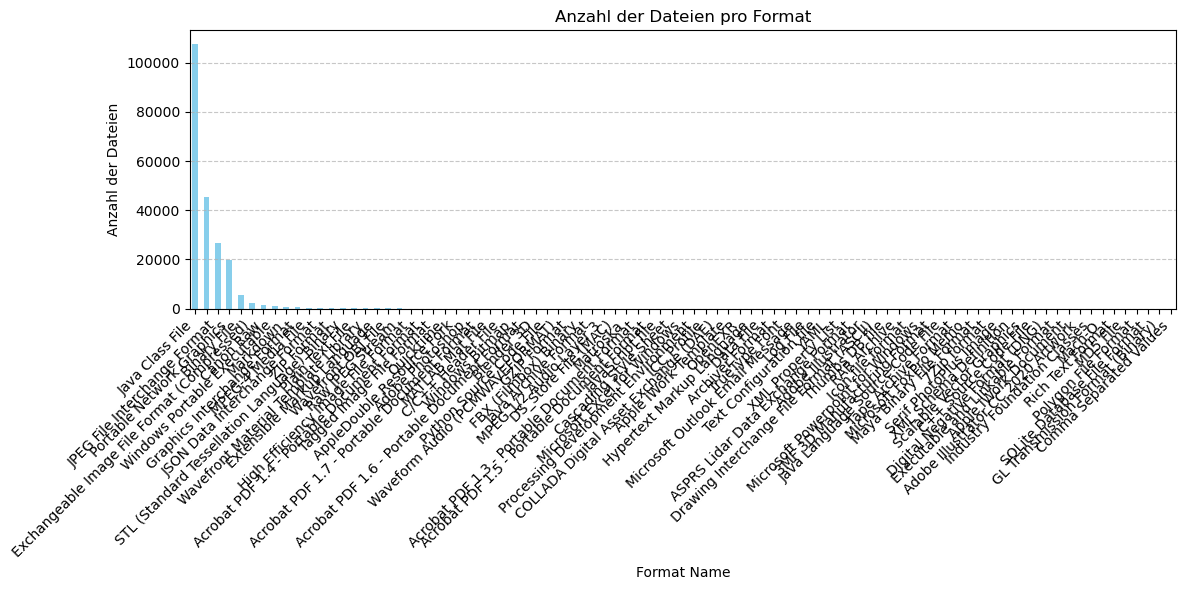

In [5]:
# Analyse: Anzahl der Dateien pro Format
import matplotlib.pyplot as plt

format_counts = droid_df['FORMAT_NAME'].value_counts()

plt.figure(figsize=(12, 6))
format_counts.plot(kind='bar', color='skyblue')
plt.title('Anzahl der Dateien pro Format')
plt.xlabel('Format Name')
plt.ylabel('Anzahl der Dateien')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "format_counts.png")
plt.savefig(output_path)
print(f"Plot gespeichert unter: {output_path}")
plt.show()


### Häufigkeit Format X über Zeit

Gefilterte Zeilen für 'Java Class File' in Spalte 'FORMAT_NAME': 107730
Parsen abgeschlossen: 0 ungültige Datumswerte (von 107730)
_parsed_dt
2021-11-10         1
2022-09-09         1
2023-01-17    107728
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/FORMAT_NAME_Java Class File_counts.png


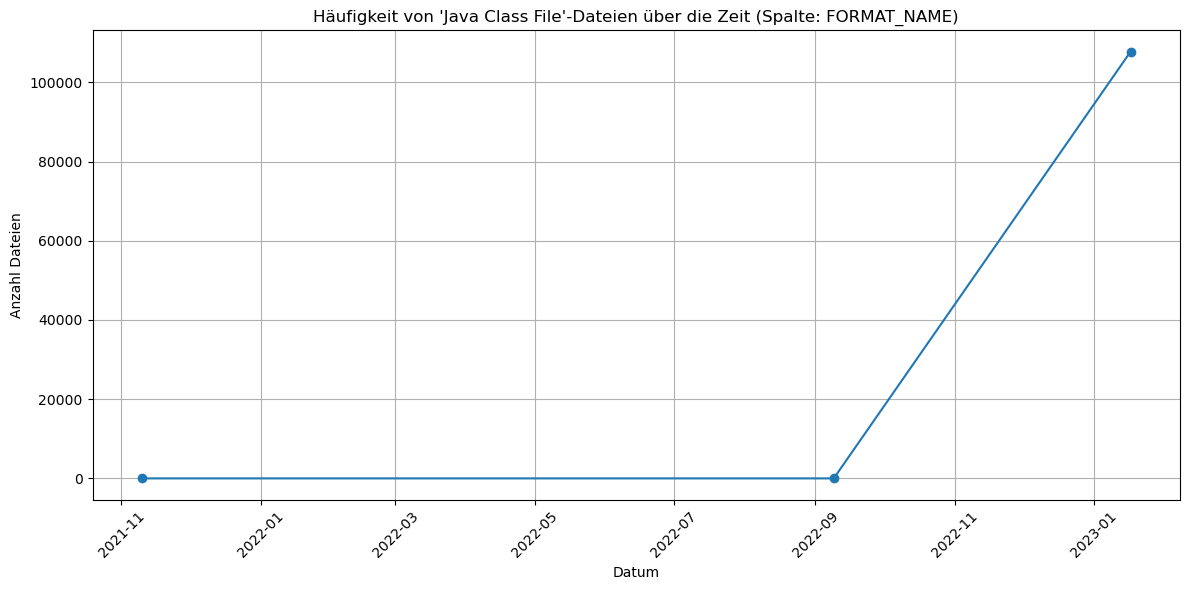

In [6]:
from analyse_format_over_creation_time import analyse_format_over_creation_time_df

most_common_format = droid_df["FORMAT_NAME"].dropna().astype(str).str.strip().value_counts().idxmax()
ts = analyse_format_over_creation_time_df(droid_df, most_common_format, date_column="LAST_MODIFIED", output_dir=output_dir, show_plot=True, verbose=True)


Gefilterte Zeilen für '3dm' in Spalte 'EXT': 198
Parsen abgeschlossen: 0 ungültige Datumswerte (von 198)
_parsed_dt
2020-04-21    1
2020-10-14    1
2020-12-16    2
2021-01-08    1
2021-02-03    1
2021-10-14    2
2021-12-04    1
2021-12-07    1
2021-12-14    2
2021-12-15    2
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/EXT_3dm_counts.png


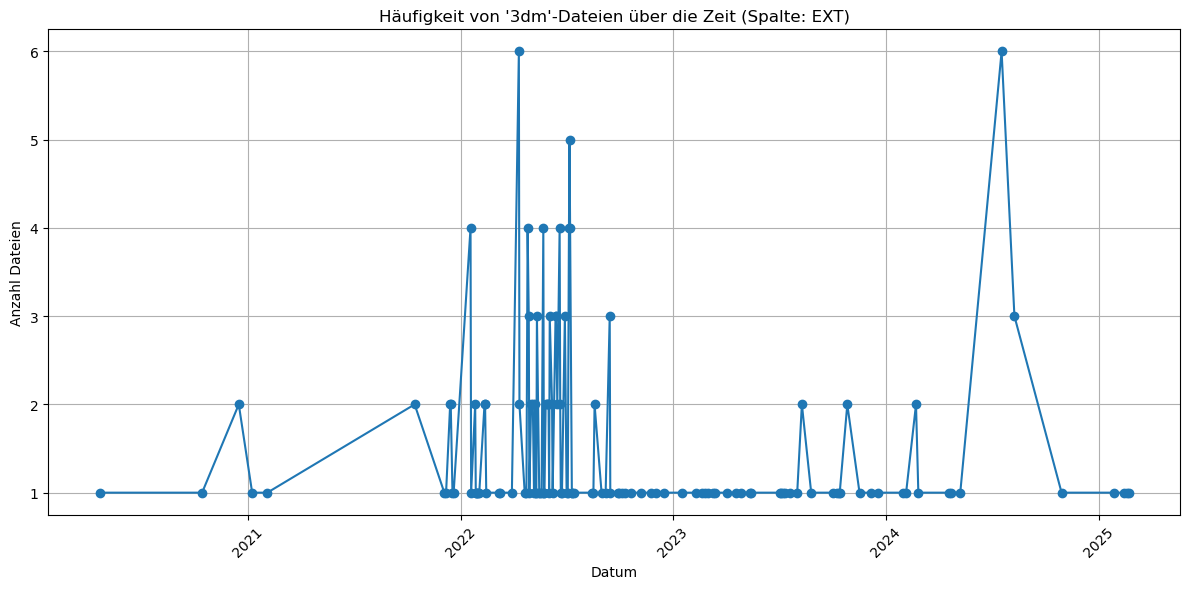

In [12]:
from analyse_format_over_creation_time import analyse_format_over_creation_time_df

format_name = "3dm"
ts = analyse_format_over_creation_time_df(droid_df, format_name, date_column="LAST_MODIFIED", output_dir=output_dir, show_plot=True, verbose=True)


In [10]:
print(droid_df[droid_df['EXT'].str.lower() == '3dm']['FORMAT_NAME'].value_counts())

FORMAT_NAME
                             194
MPEG 1/2 Audio Layer 3         3
AppleDouble Resource Fork      1
Name: count, dtype: int64


In [8]:
df = droid_df.copy()
df['LAST_MODIFIED'] = pd.to_datetime(df['LAST_MODIFIED'], errors='coerce')
# Case-insensitive filter (Daten haben 'FORMAT_NAME' als '3DM' uppercase)
df_3dm = df[df['FORMAT_NAME'].str.upper() == '3DM']
print(f"Anzahl 3DM-Zeilen: {len(df_3dm)}")
print(df_3dm['LAST_MODIFIED'].describe())
print(df_3dm['LAST_MODIFIED'].dt.year.value_counts().sort_index())


Anzahl 3DM-Zeilen: 0
count      0
mean     NaT
min      NaT
25%      NaT
50%      NaT
75%      NaT
max      NaT
Name: LAST_MODIFIED, dtype: object
Series([], Name: count, dtype: int64)


In [9]:
# Identifizieren eines repräsentativen 3D Dokuments: Schritt 1 zeitliche Analyse

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df = droid_df.copy()
df['LAST_MODIFIED'] = pd.to_datetime(df['LAST_MODIFIED'], errors='coerce')

def filter_3dm_files_by_dates(df, start_date, end_date):
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    return df[(df['FORMAT_NAME'] == '3DM') & (df['LAST_MODIFIED'].between(start_date, end_date))]

result = filter_3dm_files_by_dates(df, '2021-01-01', '2023-12-31')
from IPython.display import display
display(result)


,ID,PARENT_ID,URI,FILE_PATH,NAME,METHOD,STATUS,SIZE,TYPE,EXT,LAST_MODIFIED,EXTENSION_MISMATCH,HASH,FORMAT_COUNT,PUID,MIME_TYPE,FORMAT_NAME,FORMAT_VERSION,ext_lower


In [ ]:
# Identifizieren eines repräsentativen 3D Dokuments: Schritt 2 kommentieren

# Kommentarspalte hinzufügen (einmalig, falls nicht vorhanden)
if 'comment' not in droid_df.columns:
    droid_df['comment'] = ''

# Kommentar in Zeile X hinzufügen
droid_df.loc[838, 'comment'] = 'Potentialy final 3D representation in Rhino'

# CSV überschreiben
droid_df.to_csv(csv_path, index=False)
print(f"Gespeichert: {csv_path}")


### Monatliche Dateihäufigkeit

Waffle-Chart für Zeitraum: 2011-2012
Plot gespeichert unter: /home/renku/work/dcaonnextcloud-500gb/dca-metadataraw/Keller/07_Plaene_Visualisierungen_results/res/waffle_files_per_month_2011_2012.png


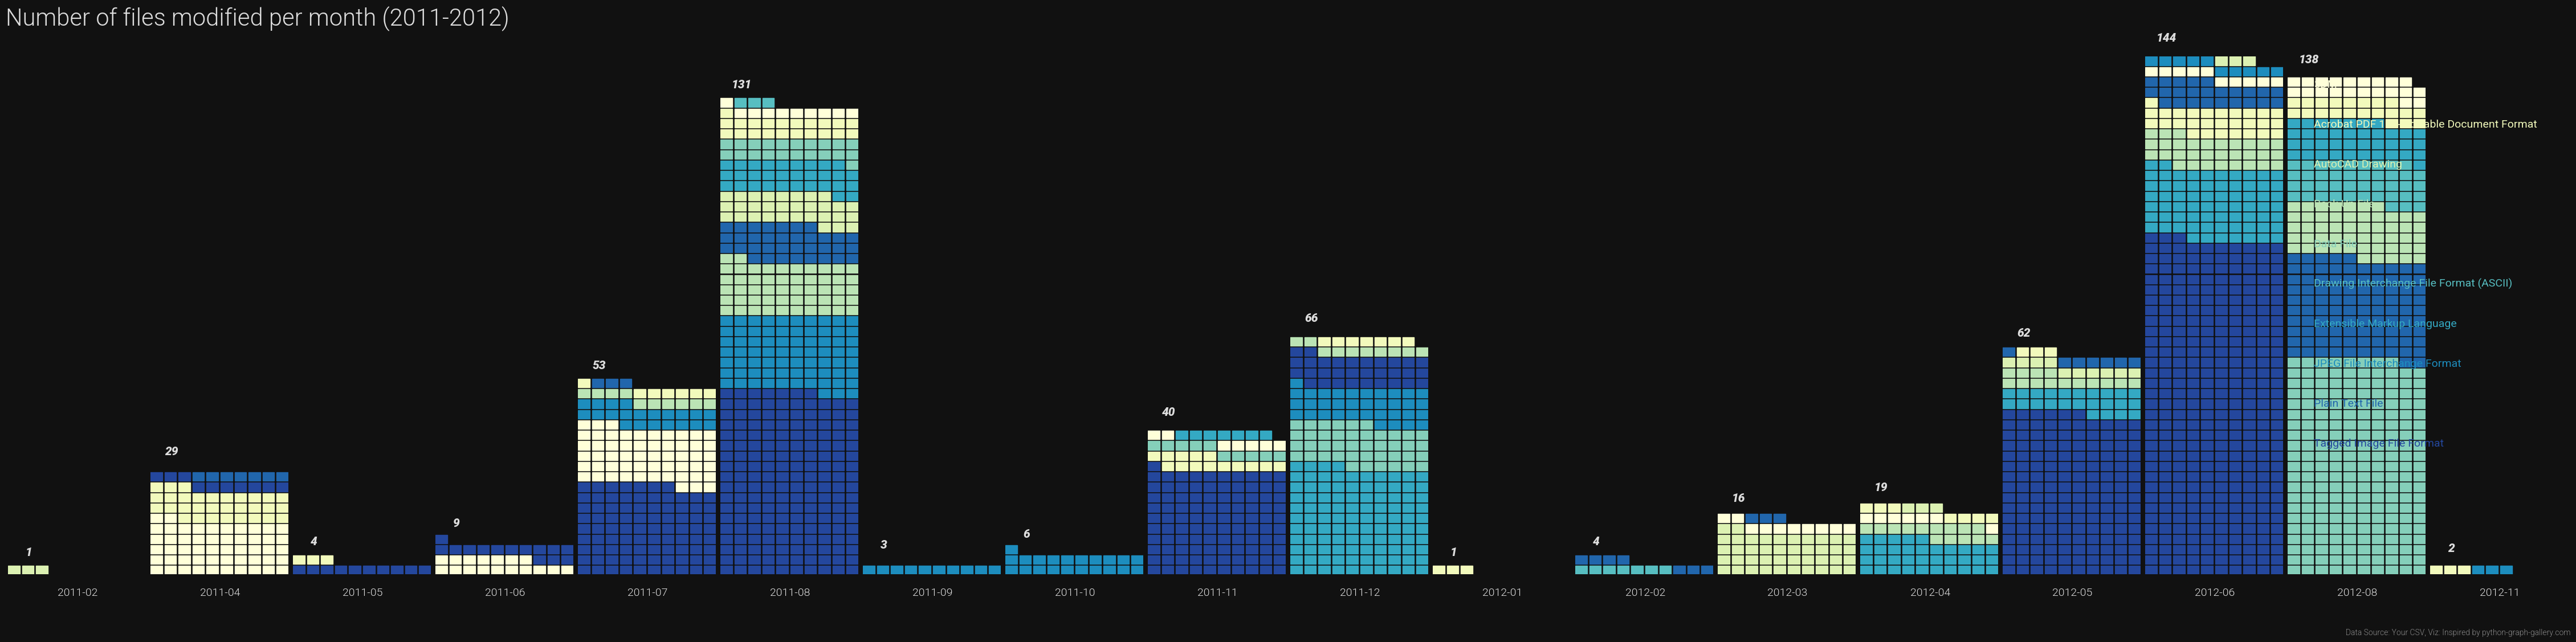

In [ ]:
# Analyse: Waffle-Chart für monatliche Dateihäufigkeit (verwende creation_iso)
from generate_waffle import generate_waffle_chart

df_waffle = droid_df.copy()
df_waffle["creation_iso"] = pd.to_datetime(df_waffle["creation_iso"], errors="coerce")
df_waffle = df_waffle.dropna(subset=["creation_iso"])

if len(df_waffle) > 0:
    start_year = 2011
    end_year = 2012
    print(f"Waffle-Chart für Zeitraum: {start_year}-{end_year}")
    generate_waffle_chart(df=df_waffle, output_dir=output_dir, start_year=start_year, end_year=end_year, top_n=10, show_plot=False, date_col="creation_iso")
else:
    print("Keine gültigen Datumsangaben in den Daten gefunden.")


### Finale Produktionsdaten

Gefilterte Zeilen für 'dat' in Spalte 'EXT': 93
Parsen abgeschlossen: 0 ungültige Datumswerte (von 93)
_parsed_dt
2010-10-18    12
2011-08-15     3
2011-08-17     3
2011-11-01     3
2011-12-13    12
2012-08-21    12
2012-08-28    48
Name: count, dtype: int64
Plot gespeichert unter: plots/EXT_dat_counts.png


/home/renku/work/27_DCA_Ingest/src/analyse_format_over_creation_time.py:43: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(s, errors='coerce', infer_datetime_format=True, utc=True)


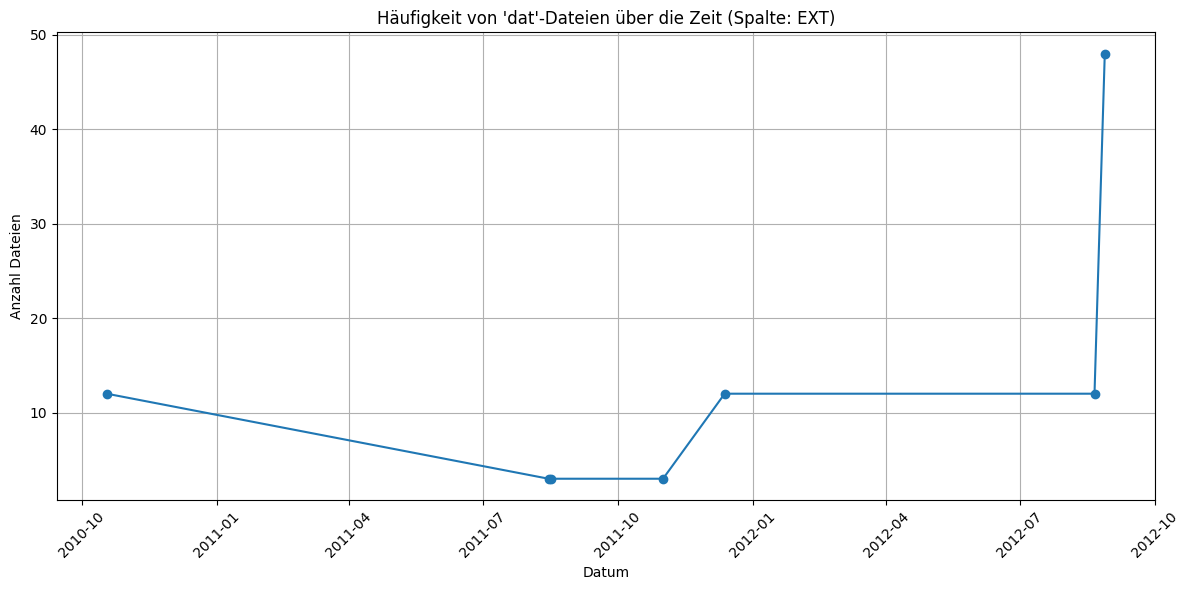

In [ ]:
# Nach dat-Dateien suchen (Steuerung KUKA Roboter) — src wird von DROID nicht als Format erkannt
from analyse_format_over_creation_time import analyse_format_over_creation_time_df

format_name = "dat"
ts = analyse_format_over_creation_time_df(droid_df, format_name, date_column="creation_iso", output_dir=output_dir, show_plot=True, verbose=True)


In [13]:
# Muss noch von LAST_MODIFIED auf creation_iso angepasst werden
# # Analyse: Heatmap der häufigsten Formate nach Monat
# try:
#     from analyse_format_heatmap import generate_format_heatmap
    
#     # Ermittle den Zeitraum aus den Daten
#     if os.path.exists(CSV_PATH):
#         df = pd.read_csv(CSV_PATH)
#         df["LAST_MODIFIED"] = pd.to_datetime(df["LAST_MODIFIED"], errors="coerce")
#         df_clean = df.dropna(subset=["LAST_MODIFIED"])
        
#         if len(df_clean) > 0:
#             start_year = df_clean["LAST_MODIFIED"].dt.year.min()
#             end_year = df_clean["LAST_MODIFIED"].dt.year.max()
#             print(f"Heatmap für Zeitraum: {start_year}-{end_year}")
#             generate_format_heatmap(CSV_PATH, OUTPUT_DIR, start_year, end_year, top_n=10, show_plot=False)
#         else:
#             print("Keine gültigen Datumsangaben in den Daten gefunden.")
#     else:
#         print(f"CSV-Datei nicht gefunden: {CSV_PATH}")
# except ImportError as e:
#     print(f"Hinweis: Modul nicht gefunden ({e}). Überspringe Heatmap.")
#     print("Installieren Sie seaborn falls benötigt: pip install seaborn")
# except Exception as e:
#     print(f"Fehler bei generate_format_heatmap: {e}")